# 时间序列变点检测分析

计算分段人数
使用多种方法（CUSUM、Bayesian Change Point、PELT等）检测五组发病数据中的变点，验证分段是否由数据驱动。


In [2]:
import pandas as pd

file_path = r"D:\app\OneDrive\Desktop\04 百日咳新策略\data\population_2010_2024.xlsx"

# ======================
# 1 湖南省总人口
# ======================

df_pop = pd.read_excel(file_path, sheet_name="Sheet1")
df_pop = df_pop[df_pop["Age"] == "0+"][["Year","Population"]]

# ======================
# 2 全国年龄结构
# ======================

df_age = pd.read_excel(file_path, sheet_name="Sheet2")

df_age = df_age[df_age["group"]!="total"]
df_age["group"] = df_age["group"].astype(int)
df_age = df_age.set_index("group")

# ======================
# 3 计算各年龄段比例
# ======================

def get_structure(year):

    if year <= 2014:
        census = 2010
    elif year <= 2019:
        census = 2015
    else:
        census = 2020

    total = df_age[census].sum()

    age0 = df_age.loc[0, census]
    age1 = df_age.loc[1, census]
    age5 = df_age.loc[5, census]
    age10 = df_age.loc[10, census]
    age15 = df_age.loc[15, census]

    age20plus = df_age.loc[20:, census].sum()

    structure = {}

    structure["0_6m"] = (age0 * 0.5) / total
    structure["6m_2y"] = (age0 * 0.5 + age1 * 0.25) / total
    structure["2_6y"] = (age1 * 0.75 + age5 * 0.2) / total
    structure["6_10y"] = (age5 * 0.8) / total
    structure["10_20y"] = (age10 + age15) / total
    structure["20_plus"] = age20plus / total

    return structure

# ======================
# 4 计算湖南年龄人口
# ======================

result = []

for _,row in df_pop.iterrows():

    year = row["Year"]
    total = row["Population"]

    struct = get_structure(year)

    result.append({
        "year":year,
        "0_6m": total*struct["0_6m"],
        "6m_2y": total*struct["6m_2y"],
        "2_6y": total*struct["2_6y"],
        "6_10y": total*struct["6_10y"],
        "10_20y": total*struct["10_20y"],
        "20_plus": total*struct["20_plus"]
    })

result_df = pd.DataFrame(result)

# ======================
# 5 保存
# ======================

out_path = r"D:\app\OneDrive\Desktop\04 百日咳新策略\data\02_age_group.csv"

result_df.to_csv(out_path, index=False)

print("完成")


完成


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
1
# 尝试导入变点检测库
try:
    import ruptures as rpt
    HAS_RUPTURES = True
except ImportError:
    print("警告: ruptures 未安装，将跳过 PELT 方法。请运行: pip install ruptures")
    HAS_RUPTURES = False

try:
    from statsmodels.stats.diagnostic import breaks_cusumolsresid
    HAS_STATSMODELS = True
except ImportError:
    print("警告: statsmodels 未安装，将跳过 CUSUM 方法。请运行: pip install statsmodels")
    HAS_STATSMODELS = False


In [3]:
# 配置与路径
N_GROUPS = 5
INCIDENCE_CSV = r"D:\app\OneDrive\Desktop\04 百日咳新策略\data\4group20-.csv"

# 加载数据
def load_incidence(csv_path: str) -> pd.DataFrame:
    """读取月度发病数：要求包含 group1..groupN 列。"""
    df = pd.read_csv(csv_path)
    df.columns = [c.strip().lower() for c in df.columns]
    for time_col in ("time", "t", "month"):
        if time_col in df.columns:
            df = df.drop(columns=[time_col])
    group_cols = [f"group{i}" for i in range(1, N_GROUPS + 1)]
    missing = [c for c in group_cols if c not in df.columns]
    if missing:
        raise ValueError(f"发病数据缺少列: {missing}")
    sub = df[group_cols].copy()
    for c in sub.columns:
        if sub[c].dtype == object:
            sub[c] = sub[c].astype(str).str.replace(",", "").str.replace(" ", "")
        sub[c] = pd.to_numeric(sub[c], errors='coerce').fillna(0.0)
    sub.columns = [f"G{i}" for i in range(1, N_GROUPS + 1)]
    return sub

inc_df = load_incidence(INCIDENCE_CSV)
n_months = inc_df.shape[0]
print(f"数据加载完成: {n_months} 个月，{N_GROUPS} 个年龄组")
print(f"数据范围: 月份 0 到 {n_months-1}")

# 现有分段（用于对比）
existing_segments = [(0, 96), (95, 120), (119, 166), (165, 180)]
existing_changepoints = [seg[1] for seg in existing_segments[:-1]]  # [96, 120, 166]
print(f"\n现有分段点: {existing_changepoints}")


数据加载完成: 180 个月，5 个年龄组
数据范围: 月份 0 到 179

现有分段点: [96, 120, 166]


## 方法1: PELT (Pruned Exact Linear Time) - 基于ruptures库


In [4]:
def detect_changepoints_pelt(data, n_bkps=None, min_size=2, penalty=None):
    """
    使用PELT算法检测变点
    
    参数:
    - data: 一维数组，时间序列数据
    - n_bkps: 期望的变点数量（None表示自动选择）
    - min_size: 最小段长度
    - penalty: 惩罚参数（None表示使用BIC）
    """
    if not HAS_RUPTURES:
        return None, None
    
    # 转换为2D数组（ruptures需要）
    data_2d = data.reshape(-1, 1)
    
    # 创建算法对象
    algo = rpt.Pelt(model="rbf", min_size=min_size)
    if penalty is not None:
        algo.fit(data_2d)
        bkps = algo.predict(pen=penalty)
    elif n_bkps is not None:
        algo = rpt.Dynp(model="rbf", min_size=min_size)
        algo.fit(data_2d)
        bkps = algo.predict(n_bkps=n_bkps)
    else:
        # 使用BIC自动选择
        algo.fit(data_2d)
        bkps = algo.predict(pen=np.log(len(data)) * np.var(data))
    
    # 移除最后一个点（数据末尾）
    changepoints = [b for b in bkps if b < len(data)]
    
    return changepoints, algo

if HAS_RUPTURES:
    print("="*60)
    print("PELT 变点检测结果")
    print("="*60)
    
    pelt_results = {}
    
    for g in range(N_GROUPS):
        data = inc_df[f"G{g+1}"].values
        
        # 尝试不同的变点数量
        changepoints_auto, _ = detect_changepoints_pelt(data, n_bkps=None, min_size=12)
        changepoints_3, _ = detect_changepoints_pelt(data, n_bkps=4, min_size=12)
        
        pelt_results[g] = {
            'auto': changepoints_auto,
            'n3': changepoints_3
        }
        
        print(f"\nGroup {g+1}:")
        print(f"  自动检测变点: {changepoints_auto}")
        print(f"  固定4个变点: {changepoints_3}")



PELT 变点检测结果

Group 1:
  自动检测变点: []
  固定4个变点: [95, 125, 145, 160]

Group 2:
  自动检测变点: []
  固定4个变点: [95, 125, 145, 160]

Group 3:
  自动检测变点: []
  固定4个变点: [100, 120, 135, 160]

Group 4:
  自动检测变点: []
  固定4个变点: [100, 120, 135, 160]

Group 5:
  自动检测变点: []
  固定4个变点: [105, 120, 135, 160]


## 方法2: CUSUM (Cumulative Sum) 测试


In [5]:
def detect_changepoints_cusum(data, alpha=0.05, max_changepoints=3, min_size=12):
    """
    使用CUSUM测试检测多个变点（递归分割方法）
    
    参数:
    - data: 时间序列数据
    - alpha: 显著性水平
    - max_changepoints: 最大变点数量
    - min_size: 最小段长度
    """
    if not HAS_STATSMODELS:
        return None, None
    
    from sklearn.linear_model import LinearRegression
    
    def cusum_test_segment(segment_data, segment_start=0):
        """对单个段进行CUSUM测试，返回变点位置（相对于segment_start）"""
        n = len(segment_data)
        if n < 2 * min_size:
            return None, None
        
        # 对段数据进行线性回归
        X = np.arange(n).reshape(-1, 1)
        y = segment_data.ravel()
        
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        residuals = y - y_pred
        
        # 使用CUSUM测试
        try:
            cusum_stat, p_value, crit_values = breaks_cusumolsresid(residuals)
            
            if p_value < alpha:
                # 计算累积残差，找到最大变化点
                cumsum_resid = np.cumsum(residuals - np.mean(residuals))
                # 找到累积和的最大变化点（相对于段开始位置）
                relative_cp = np.argmax(np.abs(cumsum_resid))
                # 转换为全局位置
                global_cp = segment_start + relative_cp
                return global_cp, p_value
            else:
                return None, p_value
        except:
            return None, None
    
    # 递归分割方法检测多个变点
    changepoints = []
    segments_to_test = [(0, len(data))]  # (start, end)
    
    while len(segments_to_test) > 0 and len(changepoints) < max_changepoints:
        new_segments = []
        
        for start, end in segments_to_test:
            segment_data = data[start:end]
            cp, p_val = cusum_test_segment(segment_data, segment_start=start)
            
            if cp is not None:
                # 找到变点，添加到列表
                if cp not in changepoints and start < cp < end:
                    changepoints.append(cp)
                
                # 将段分割为两部分，继续检测
                if cp - start >= min_size:
                    new_segments.append((start, cp))
                if end - cp >= min_size:
                    new_segments.append((cp, end))
            else:
                # 未找到变点，不再分割
                pass
        
        segments_to_test = new_segments
    
    # 如果递归方法没找到足够的变点，使用全局CUSUM找到最显著的变点
    if len(changepoints) == 0:
        X = np.arange(len(data)).reshape(-1, 1)
        y = data.ravel()
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        residuals = y - y_pred
        
        try:
            cusum_stat, p_value, crit_values = breaks_cusumolsresid(residuals)
            if p_value < alpha:
                cumsum_resid = np.cumsum(residuals - np.mean(residuals))
                changepoint = np.argmax(np.abs(cumsum_resid))
                changepoints = [changepoint]
                return changepoints, p_value
            else:
                return [], p_value
        except:
            return None, None
    
    # 对变点进行排序和去重
    changepoints = sorted(list(set(changepoints)))
    
    # 计算整体p值（使用第一个变点的p值作为参考）
    X = np.arange(len(data)).reshape(-1, 1)
    y = data.ravel()
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    residuals = y - y_pred
    try:
        cusum_stat, p_value, crit_values = breaks_cusumolsresid(residuals)
    except:
        p_value = None
    
    return changepoints, p_value

if HAS_STATSMODELS:
    print("="*60)
    print("CUSUM 变点检测结果")
    print("="*60)
    
    cusum_results = {}
    
    for g in range(N_GROUPS):
        data = inc_df[f"G{g+1}"].values
        changepoints, p_value = detect_changepoints_cusum(data, alpha=0.05, max_changepoints=3, min_size=12)
        
        cusum_results[g] = {
            'changepoints': changepoints if changepoints else [],
            'p_value': p_value
        }
        
        print(f"\nGroup {g+1}:")
        if changepoints:
            print(f"  检测到变点: {changepoints}")
        if p_value is not None:
            print(f"  P值: {p_value:.4f}")
else:
    cusum_results = None
    print("跳过CUSUM检测（库未安装）")


CUSUM 变点检测结果

Group 1:
  检测到变点: [97, 117, 161]
  P值: 0.0036

Group 2:
  检测到变点: [99, 121, 167]
  P值: 0.0037

Group 3:
  检测到变点: [99, 158, 166]
  P值: 0.0007

Group 4:
  检测到变点: [134, 158, 166]
  P值: 0.0006

Group 5:
  检测到变点: [103, 146, 166]
  P值: 0.0017


## 方法5: 基于信息准则的变点检测（AIC/BIC）


In [6]:
# 方法5: 基于信息准则（AIC/BIC）的变点检测
def detect_changepoints_ic(data, max_changepoints=4, criterion='BIC', min_size=12):
    """
    使用信息准则（AIC/BIC）检测变点
    通过比较不同分段数量的模型来选择最优变点
    """
    n = len(data)
    if n < 2 * min_size:
        return []
    
    def calculate_ic(changepoints):
        """计算给定变点位置的信息准则值"""
        if not changepoints:
            # 无变点：单一模型
            mu = np.mean(data)
            sigma = np.std(data)
            if sigma == 0:
                return np.inf
            log_likelihood = -0.5 * n * (np.log(2 * np.pi * sigma**2) + 1)
            k = 2  # 均值和方差两个参数
        else:
            # 有变点：分段模型
            segments = [0] + sorted(changepoints) + [n]
            log_likelihood = 0
            k = 0
            for i in range(len(segments) - 1):
                seg_data = data[segments[i]:segments[i+1]]
                if len(seg_data) < 2:
                    return np.inf
                mu = np.mean(seg_data)
                sigma = np.std(seg_data)
                if sigma == 0:
                    sigma = 1e-10
                seg_n = len(seg_data)
                log_likelihood += -0.5 * seg_n * (np.log(2 * np.pi * sigma**2) + 1)
                k += 2  # 每段的均值和方差
        
        if criterion == 'AIC':
            ic = -2 * log_likelihood + 2 * k
        else:  # BIC
            ic = -2 * log_likelihood + k * np.log(n)
        
        return ic
    
    # 尝试不同数量的变点
    best_ic = np.inf
    best_changepoints = []
    
    for n_cps in range(max_changepoints + 1):
        if n_cps == 0:
            # 无变点情况
            ic = calculate_ic([])
            if ic < best_ic:
                best_ic = ic
                best_changepoints = []
        else:
            # 有变点：使用动态规划或贪心方法找到最优位置
            # 简化版本：在合理范围内搜索
            search_range = range(min_size, n - min_size, max(1, (n - 2*min_size) // 20))
            
            if n_cps == 1:
                # 单个变点：直接搜索
                for cp in search_range:
                    ic = calculate_ic([cp])
                    if ic < best_ic:
                        best_ic = ic
                        best_changepoints = [cp]
            elif n_cps == 2:
                # 两个变点：搜索所有组合
                for cp1 in search_range:
                    for cp2 in search_range:
                        if cp2 > cp1 + min_size:
                            ic = calculate_ic([cp1, cp2])
                            if ic < best_ic:
                                best_ic = ic
                                best_changepoints = [cp1, cp2]
            elif n_cps == 3:
                # 三个变点：搜索（限制搜索空间以提高速度）
                step = max(1, len(search_range) // 10)
                for cp1 in search_range[::step]:
                    for cp2 in search_range[::step]:
                        if cp2 > cp1 + min_size:
                            for cp3 in search_range[::step]:
                                if cp3 > cp2 + min_size:
                                    ic = calculate_ic([cp1, cp2, cp3])
                                    if ic < best_ic:
                                        best_ic = ic
                                        best_changepoints = [cp1, cp2, cp3]
            elif n_cps == 4:
                # 四个变点：搜索（限制搜索空间以提高速度）
                step = max(1, len(search_range) // 10)
                for cp1 in search_range[::step]:
                    for cp2 in search_range[::step]:
                        if cp2 > cp1 + min_size:
                            for cp3 in search_range[::step]:
                                if cp3 > cp2 + min_size:
                                    for cp4 in search_range[::step]:
                                        if cp4 > cp3 + min_size:
                                            ic = calculate_ic([cp1, cp2, cp3, cp4])
                                            if ic < best_ic:
                                                best_ic = ic
                                                best_changepoints = [cp1, cp2, cp3, cp4]
    
    return sorted(best_changepoints)

print("="*60)
print("基于信息准则（BIC）的变点检测")
print("="*60)

ic_results = {}

for g in range(N_GROUPS):
    data = inc_df[f"G{g+1}"].values
    changepoints = detect_changepoints_ic(data, max_changepoints=4, criterion='BIC', min_size=12)
    
    ic_results[g] = changepoints
    
    print(f"\nGroup {g+1}: 变点位置 {changepoints}")


基于信息准则（BIC）的变点检测

Group 1: 变点位置 [96, 124, 138, 166]

Group 2: 变点位置 [54, 96, 124, 166]

Group 3: 变点位置 [96, 159]

Group 4: 变点位置 [12, 26, 40, 96]

Group 5: 变点位置 [12, 40, 68, 152]


In [10]:
# 汇总所有方法的检测结果
print(f"现有分段点: {existing_changepoints}")
print("\n各方法检测到的变点:")

all_methods = {}

for g in range(N_GROUPS):
    print(f"\nGroup {g+1}:")
    group_results = {}
    
    if pelt_results and g in pelt_results:
        pelt_cps = pelt_results[g].get('n3', [])
        group_results['PELT'] = pelt_cps
        print(f"  PELT: {pelt_cps}")
    
    if cusum_results and g in cusum_results:
        cusum_cps = cusum_results[g].get('changepoints', [])
        group_results['CUSUM'] = cusum_cps
        print(f"  CUSUM: {cusum_cps}")
    
    
    if 'ic_results' in globals() and ic_results and g in ic_results:
        ic_cps = ic_results[g]
        group_results['BIC'] = ic_cps
        print(f"  BIC: {ic_cps}")
    
    all_methods[g] = group_results


现有分段点: [96, 120, 166]

各方法检测到的变点:

Group 1:
  PELT: [95, 125, 145, 160]
  CUSUM: [97, 117, 161]
  BIC: [96, 124, 138, 166]

Group 2:
  PELT: [95, 125, 145, 160]
  CUSUM: [99, 121, 167]
  BIC: [54, 96, 124, 166]

Group 3:
  PELT: [100, 120, 135, 160]
  CUSUM: [99, 158, 166]
  BIC: [96, 159]

Group 4:
  PELT: [100, 120, 135, 160]
  CUSUM: [134, 158, 166]
  BIC: [12, 26, 40, 96]

Group 5:
  PELT: [105, 120, 135, 160]
  CUSUM: [103, 146, 166]
  BIC: [12, 40, 68, 152]


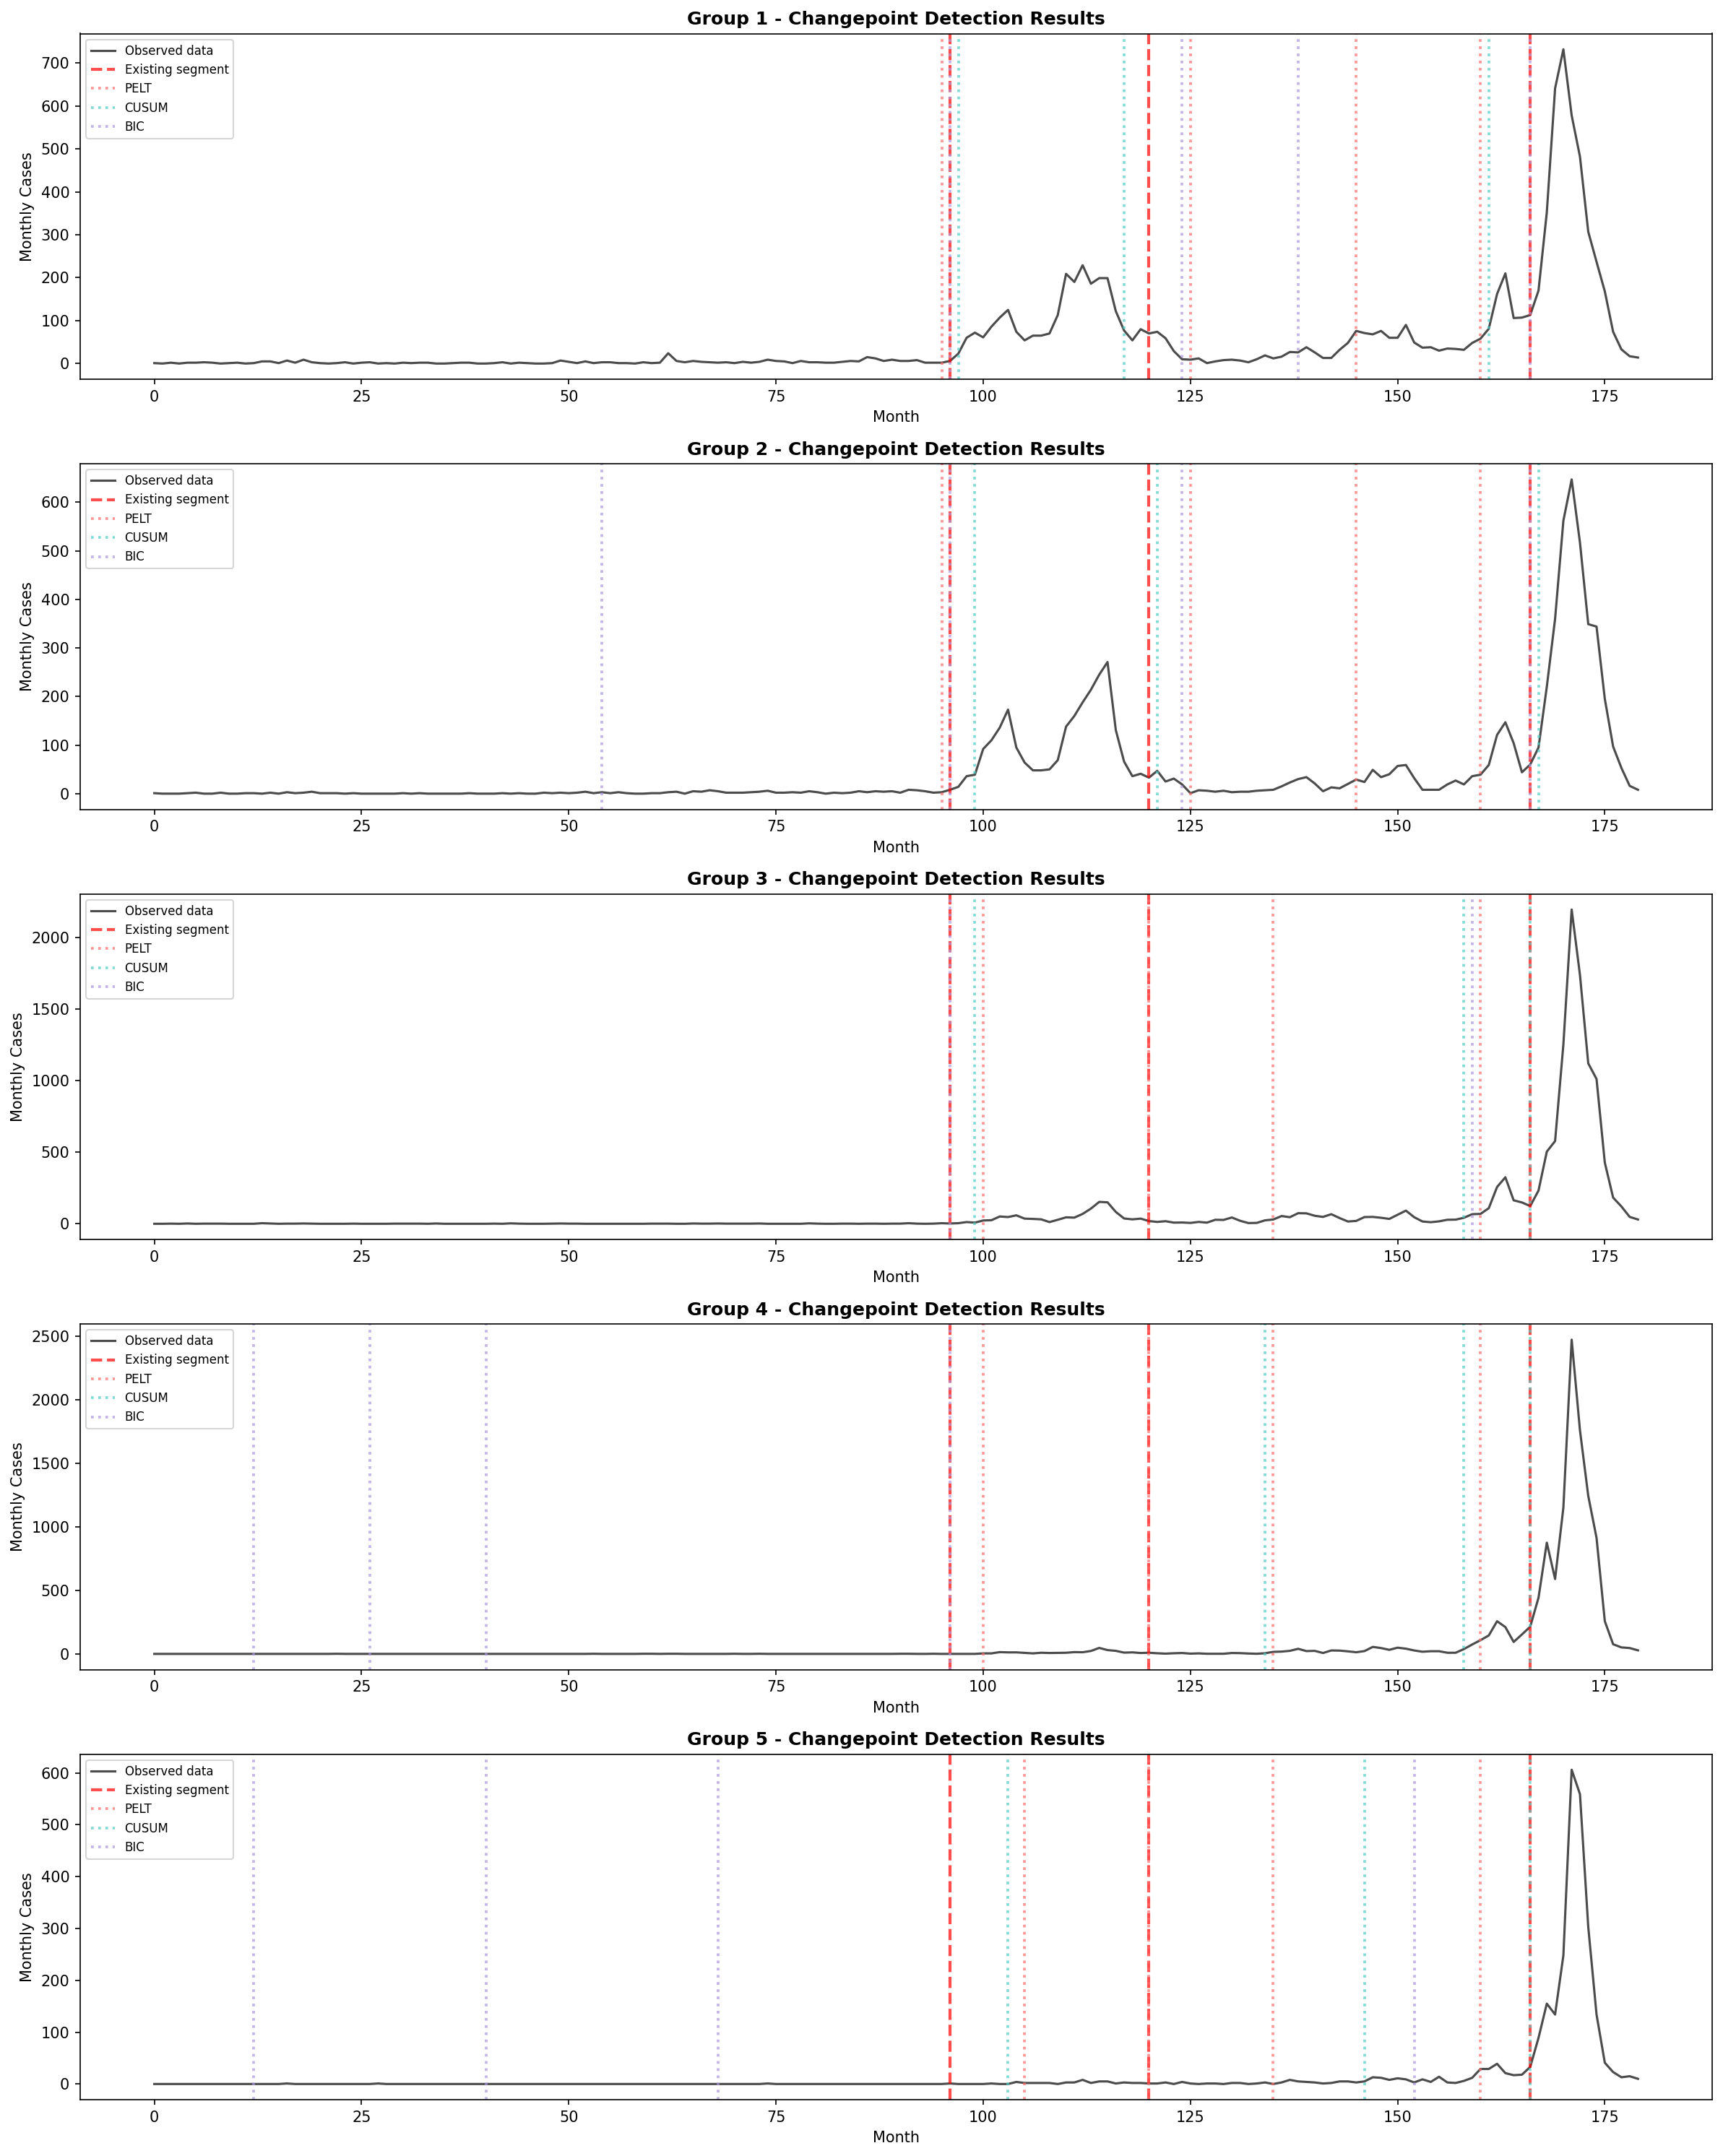


图表已保存为: changepoint_detection_results.png


In [8]:
# 可视化结果
fig, axes = plt.subplots(N_GROUPS, 1, figsize=(16, 4*N_GROUPS))
if N_GROUPS == 1:
    axes = [axes]

colors_methods = {
    'PELT': '#FF6B6B',
    'CUSUM': '#4ECDC4',
    'BIC': '#AA96DA',
    'Bayesian': '#AA96DA'
}

for g in range(N_GROUPS):
    ax = axes[g]
    data = inc_df[f"G{g+1}"].values
    months = np.arange(len(data))
    
    # 绘制原始数据
    ax.plot(months, data, 'k-', linewidth=1.5, label='Observed data', alpha=0.7)
    
    # 绘制现有分段点
    for cp in existing_changepoints:
        if cp < len(data):
            ax.axvline(x=cp, color='red', linestyle='--', linewidth=2, 
                      alpha=0.7, label='Existing segment' if cp == existing_changepoints[0] else '')
    
    # 绘制各方法检测到的变点
    if g in all_methods:
        for method, changepoints in all_methods[g].items():
            if changepoints:
                color = colors_methods.get(method, 'gray')
                for cp in changepoints:
                    if cp < len(data):
                        ax.axvline(x=cp, color=color, linestyle=':', 
                                 linewidth=1.8, alpha=0.7, 
                                 label=f'{method}' if cp == changepoints[0] else '')
    
    ax.set_title(f'Group {g+1} - Changepoint Detection Results', 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Month', fontsize=10)
    ax.set_ylabel('Monthly Cases', fontsize=10)
    ax.legend(loc='upper left', fontsize=8)


plt.tight_layout()
plt.savefig('changepoint_detection_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n图表已保存为: changepoint_detection_results.png")


In [9]:
# 分析各方法检测到的变点与现有分段的一致性
def find_nearest_changepoint(target, changepoints, tolerance=12):
    """找到最接近目标点的变点（在容差范围内）"""
    if not changepoints:
        return None, None
    distances = [abs(cp - target) for cp in changepoints]
    min_dist = min(distances)
    if min_dist <= tolerance:
        idx = distances.index(min_dist)
        return changepoints[idx], min_dist
    return None, None

print("="*60)
print("变点一致性分析")
print("="*60)
print(f"现有分段点: {existing_changepoints}")
print(f"容差范围: ±12个月")

consistency_summary = {}

for g in range(N_GROUPS):
    print(f"\nGroup {g+1}:")
    group_consistency = {}
    
    if g in all_methods:
        for method, changepoints in all_methods[g].items():
            matches = []
            for existing_cp in existing_changepoints:
                nearest, dist = find_nearest_changepoint(existing_cp, changepoints, tolerance=12)
                if nearest is not None:
                    matches.append((existing_cp, nearest, dist))
            
            group_consistency[method] = matches
            
            if matches:
                print(f"  {method}: 匹配到 {len(matches)}/{len(existing_changepoints)} 个现有分段点")
                for existing, detected, dist in matches:
                    print(f"    现有点 {existing} <-> 检测点 {detected} (距离: {dist}个月)")
            else:
                print(f"  {method}: 未匹配到现有分段点")
    
    consistency_summary[g] = group_consistency

# 计算总体一致性
print("\n" + "="*60)
print("总体一致性统计")
print("="*60)

for method in ['PELT', 'CUSUM', 'BIC']:
    total_matches = 0
    total_existing = 0
    
    for g in range(N_GROUPS):
        if g in consistency_summary and method in consistency_summary[g]:
            matches = consistency_summary[g][method]
            total_matches += len(matches)
            total_existing += len(existing_changepoints)
    
    if total_existing > 0:
        match_rate = total_matches / total_existing * 100
        print(f"{method}: {total_matches}/{total_existing} ({match_rate:.1f}%)")


变点一致性分析
现有分段点: [96, 120, 166]
容差范围: ±12个月

Group 1:
  PELT: 匹配到 3/3 个现有分段点
    现有点 96 <-> 检测点 95 (距离: 1个月)
    现有点 120 <-> 检测点 125 (距离: 5个月)
    现有点 166 <-> 检测点 160 (距离: 6个月)
  CUSUM: 匹配到 3/3 个现有分段点
    现有点 96 <-> 检测点 97 (距离: 1个月)
    现有点 120 <-> 检测点 117 (距离: 3个月)
    现有点 166 <-> 检测点 161 (距离: 5个月)
  BIC: 匹配到 3/3 个现有分段点
    现有点 96 <-> 检测点 96 (距离: 0个月)
    现有点 120 <-> 检测点 124 (距离: 4个月)
    现有点 166 <-> 检测点 166 (距离: 0个月)

Group 2:
  PELT: 匹配到 3/3 个现有分段点
    现有点 96 <-> 检测点 95 (距离: 1个月)
    现有点 120 <-> 检测点 125 (距离: 5个月)
    现有点 166 <-> 检测点 160 (距离: 6个月)
  CUSUM: 匹配到 3/3 个现有分段点
    现有点 96 <-> 检测点 99 (距离: 3个月)
    现有点 120 <-> 检测点 121 (距离: 1个月)
    现有点 166 <-> 检测点 167 (距离: 1个月)
  BIC: 匹配到 3/3 个现有分段点
    现有点 96 <-> 检测点 96 (距离: 0个月)
    现有点 120 <-> 检测点 124 (距离: 4个月)
    现有点 166 <-> 检测点 166 (距离: 0个月)

Group 3:
  PELT: 匹配到 3/3 个现有分段点
    现有点 96 <-> 检测点 100 (距离: 4个月)
    现有点 120 <-> 检测点 120 (距离: 0个月)
    现有点 166 <-> 检测点 160 (距离: 6个月)
  CUSUM: 匹配到 2/3 个现有分段点
    现有点 96 <-> 检测点 99 (距离: 3个月)
    现有点 16

## 结论

基于多种变点检测方法的结果，可以评估现有分段是否由数据驱动：

1. **如果多种方法都检测到与现有分段点相近的变点**，说明分段是数据驱动的。
2. **如果检测到的变点与现有分段差异较大**，可能需要重新考虑分段策略。
3. **不同方法的结果可以相互验证**，提高结论的可靠性。

**建议：**
- 优先考虑PELT和基于统计的方法（CUSUM）的结果
- 结合多个年龄组的结果，寻找共同的变点模式
- 考虑变点的生物学/流行病学意义
